# Market Field Calculus v1: preliminary validation v2

## tl;dr

This notebook reruns an engineering and descriptive-empirical audit from a locally retained, hash-identified data snapshot. The tested field passed **46/46** unrounded prefix checks across **24,472** numeric comparisons with maximum error **0.0**. That strong non-anticipative-computation result coexists with material initialization sensitivity: the current **96-bar** option availability threshold produced median IQR-normalized error **0.035** against full-history endpoints. A constant-price path still anchors Structure at **0.42** and display confidence at **0.68**. These are implementation, initialization-coverage, and semantic diagnostics—not evidence of forecast skill or trading performance.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd()
run = subprocess.run(
    [sys.executable, "evaluate_market_field.py"],
    cwd=HERE,
    check=True,
    capture_output=True,
    text=True,
)
summary = json.loads((HERE / "results" / "summary.json").read_text(encoding="utf-8"))
print(f"Executed with Python {sys.version.split()[0]}")
print(f"Recomputed {summary['dataset_count']} datasets / {summary['completed_bar_count']:,} completed bars in {summary['runtime_seconds']:.1f}s")

Executed with Python 3.13.14
Recomputed 15 datasets / 9,235 completed bars in 54.6s


## Context & Methods

The audit asks whether the current implementation is nonanticipative at tested prefixes, repeatable, sensitive to limited retained history, sensitive to horizon-grid and permutation-entropy choices, well-defined across supported timeframes, and semantically honest at a constant-price anchor. It also measures same-state calibration support, the options wrapper's completed-bar and zero-algorithmic-authority boundaries, and the sequential compute-only latency distribution.

The prefix check compares full-history outputs with outputs recomputed from 60%, 80%, and 95% prefixes for all live channels, derivatives, strata, carriers, and carrier ratios. A separate stress test mutates the full future suffix after a SPY-daily cutoff. It runs at both API precision and with only response rounding bypassed. The history audit recomputes the last 32 values from trailing windows of 60–365 bars. The resolution check treats horizons 8–64 at step 1 as a numerical reference, while the entropy audit compares trailing-pattern windows against the production setting of 24. Lexicons use chronological fit, calibration, and evaluation partitions.

### Key Assumptions

- The locally retained Yahoo snapshot is adequate for engineering diagnostics but is not exchange-grade data. Raw CSVs are not redistributed, so a fresh clone cannot reproduce the historical hashes offline.
- A bar is eligible only under the completion rules recorded in the manifest.
- Exact-zero audit results include unrounded float outputs from the production transform, but still describe finite tested prefixes rather than a theorem over all possible input series.
- Highly autocorrelated bars and overlapping outcomes are not independent samples.
- The learned lexicon is retrospective and excluded from the options field overlay.
- No P&L, forecast target, transaction cost, or statistical discovery hypothesis is evaluated here.

## Data

In [2]:
manifest = json.loads((HERE / "data" / "raw" / "manifest.json").read_text(encoding="utf-8"))
profile = pd.read_csv(HERE / "results" / "dataset_profile.csv")
quality = pd.DataFrame([summary["data_quality"]])
display(quality)
display(profile[["dataset_id", "symbol", "timeframe", "rows", "coverage_start", "coverage_end"]])
print("Snapshot:", manifest["observed_at_utc"])
print("Provider:", manifest["provider"], "/", manifest["provider_package"])

,all_monotonic,duplicate_timestamps,incomplete_rows_excluded,invalid_ohlcv_rows,missing_ohlcv_cells
0,True,0,15,0,0


,dataset_id,symbol,timeframe,rows,coverage_start,coverage_end
0,btc_usd_1d,BTC-USD,1D,749,2024-07-03T00:00:00+00:00,2026-07-21T00:00:00+00:00
1,gld_1d,GLD,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
2,iwm_1d,IWM,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
3,qqq_1d,QQQ,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
4,spy_15m,SPY,15m,499,2026-06-24T14:30:00+00:00,2026-07-22T15:30:00+00:00
5,spy_1d,SPY,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
6,spy_1w,SPY,1W,499,2016-12-26T05:00:00+00:00,2026-07-13T04:00:00+00:00
7,spy_1h,SPY,1h,499,2026-04-09T13:30:00+00:00,2026-07-22T14:30:00+00:00
8,spy_1m,SPY,1m,499,2026-07-21T13:59:00+00:00,2026-07-22T15:47:00+00:00
9,spy_2h,SPY,2h,499,2026-01-20T16:30:00+00:00,2026-07-22T13:30:00+00:00


Snapshot: 2026-07-22T15:48:24.325098+00:00
Provider: Yahoo Finance via yfinance YahooProvider / yfinance 1.1.0


## Results

,diagnostic,checks,max_abs_error,passes,tolerance,numeric_value_comparisons,scope,max_unique_hashes
0,prefix invariance,46,0.0,46,1.000000e-04,NaN,NaN,NaN
1,unrounded prefix invariance,46,0.0,46,1.000000e-12,24472.0,Live field matrices plus aggregate derivatives...,NaN
2,determinism,16,NaN,16,NaN,NaN,NaN,1.0


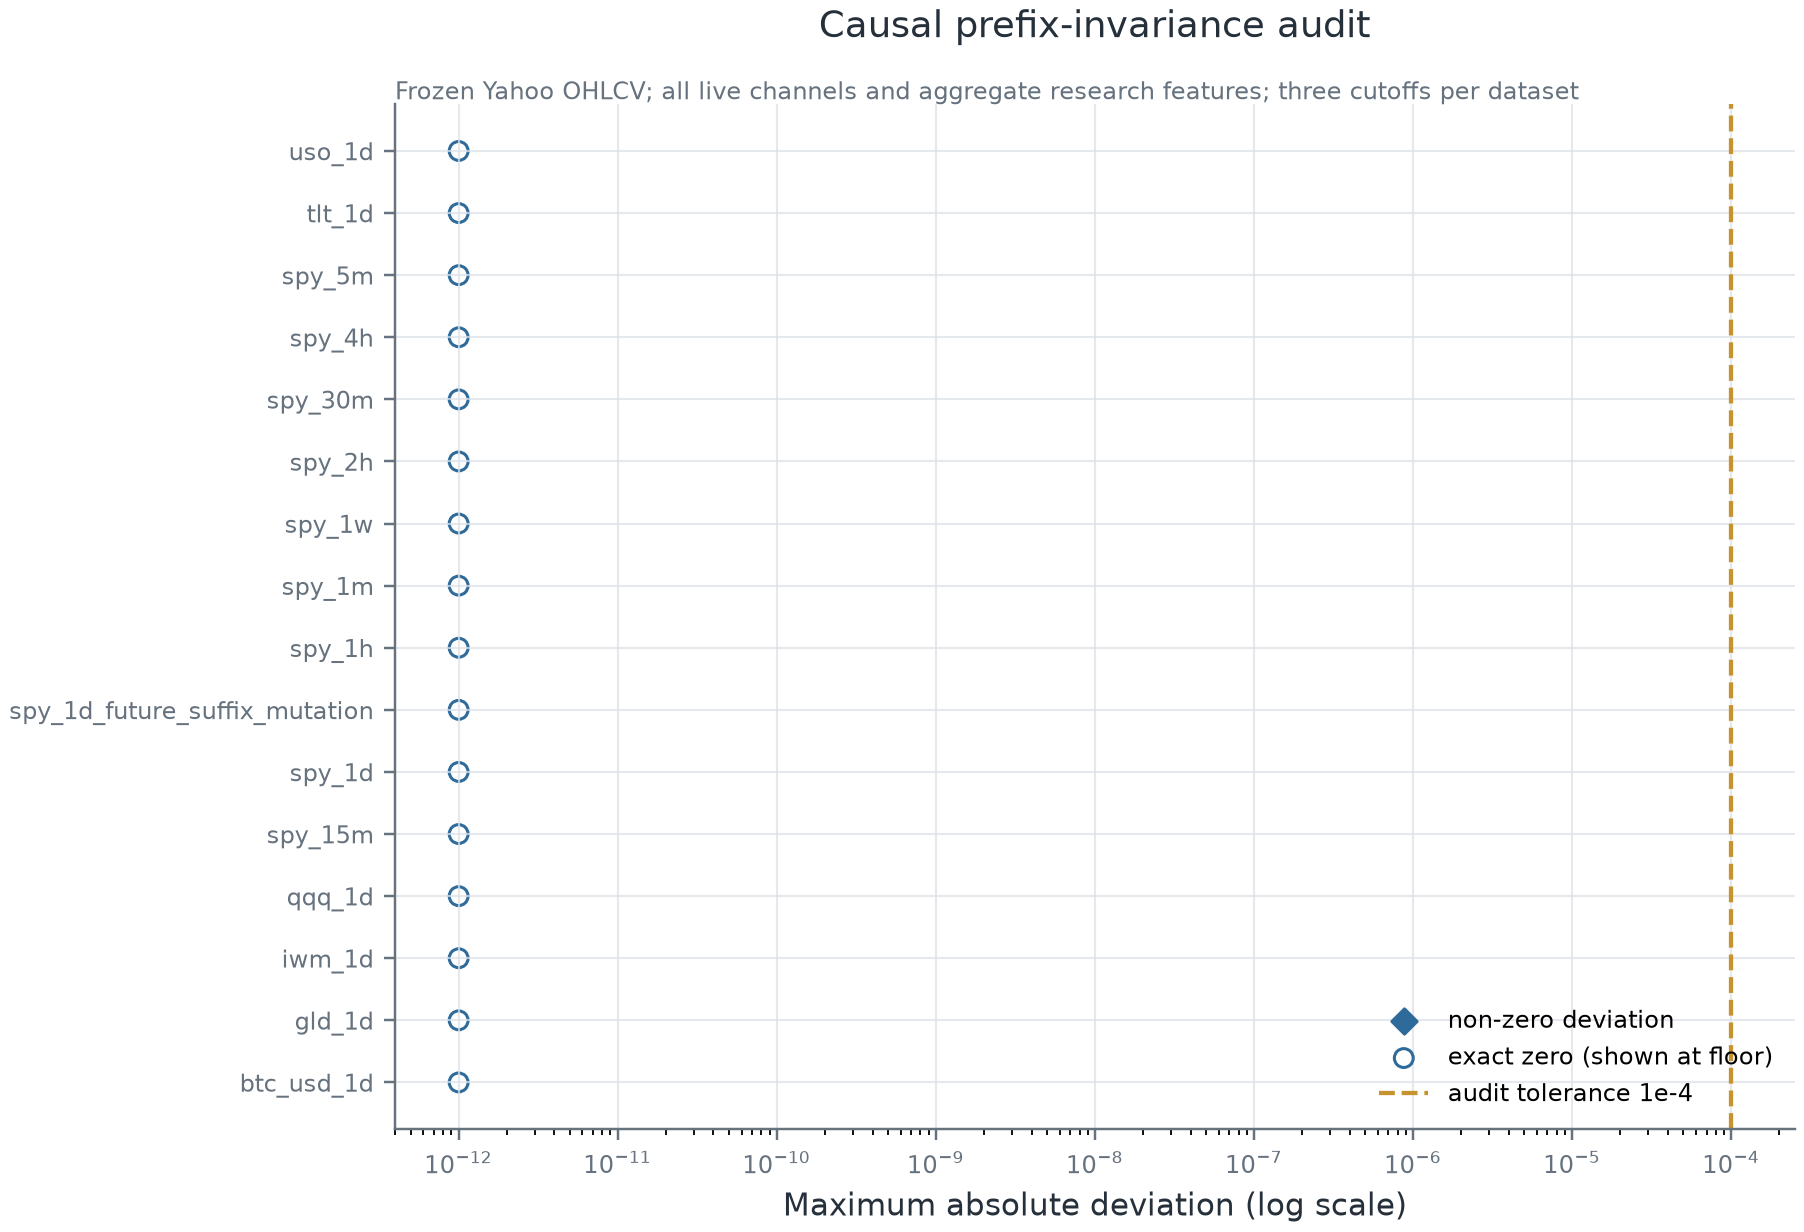

In [3]:
audit = pd.DataFrame([
    {"diagnostic": "prefix invariance", **summary["prefix_invariance"]},
    {"diagnostic": "unrounded prefix invariance", **summary["prefix_invariance_full_precision"]},
    {"diagnostic": "determinism", **summary["determinism"]},
])
display(audit)
display(Image(filename=str(HERE / "figures" / "fig_causal_prefix_audit.png")))

,input_window_bars,median,p90
0,60,5.009677e-01,2.008645
1,96,3.542178e-02,0.931382
2,128,5.515255e-03,0.456841
3,192,4.062618e-04,0.117565
4,256,2.426960e-05,0.030441
5,365,2.805002e-07,0.003152


,path,visible_bars,hidden_prefetch_bars,computation_bars,aggregate_initialization_contract,note,longest_horizon_bars,carrier_reference_span_bars,bars_per_longest_horizon,reference_span_coverage,post_longest_horizon_observations,meets_reference_span,aggregate_initialization_metadata_emitted,per_coordinate_initialization_mask_emitted
0,option_snapshot_minimum,96,0,96,initialization (maturity is a legacy alias),Accepted by the option wrapper; minimum-input ...,48,96,2.000000,1.0,48,True,True,False
1,public_api_min_visible_60_h48,60,96,156,history_context,The endpoint computes on the fetched prefix pl...,48,96,3.250000,1.0,108,True,True,False
2,paper_compute_benchmark_365,365,0,365,history_context,The paper's cached option-snapshot timing wind...,48,96,7.604167,1.0,317,True,True,False


,scenario,bars,pressure,velocity,structural_strength,coherence,legacy_disorder,permutation_entropy,structure,information,propagation,display_confidence,volume_carriers_available,semantic_interpretation
0,constant_price_positive_volume,256,0.0,0.0,0.0,1.0,0.0,0.0,0.42,0.0,0.0,0.68,True,Nonzero structure/confidence are formula ancho...
1,constant_price_zero_volume,256,0.0,0.0,0.0,1.0,0.0,0.0,0.42,0.0,0.0,0.68,False,Nonzero structure/confidence are formula ancho...


,window_patterns,entropy_correlation_vs_window24
0,8,0.450674
1,12,0.630115
2,48,0.605713
3,96,0.341653


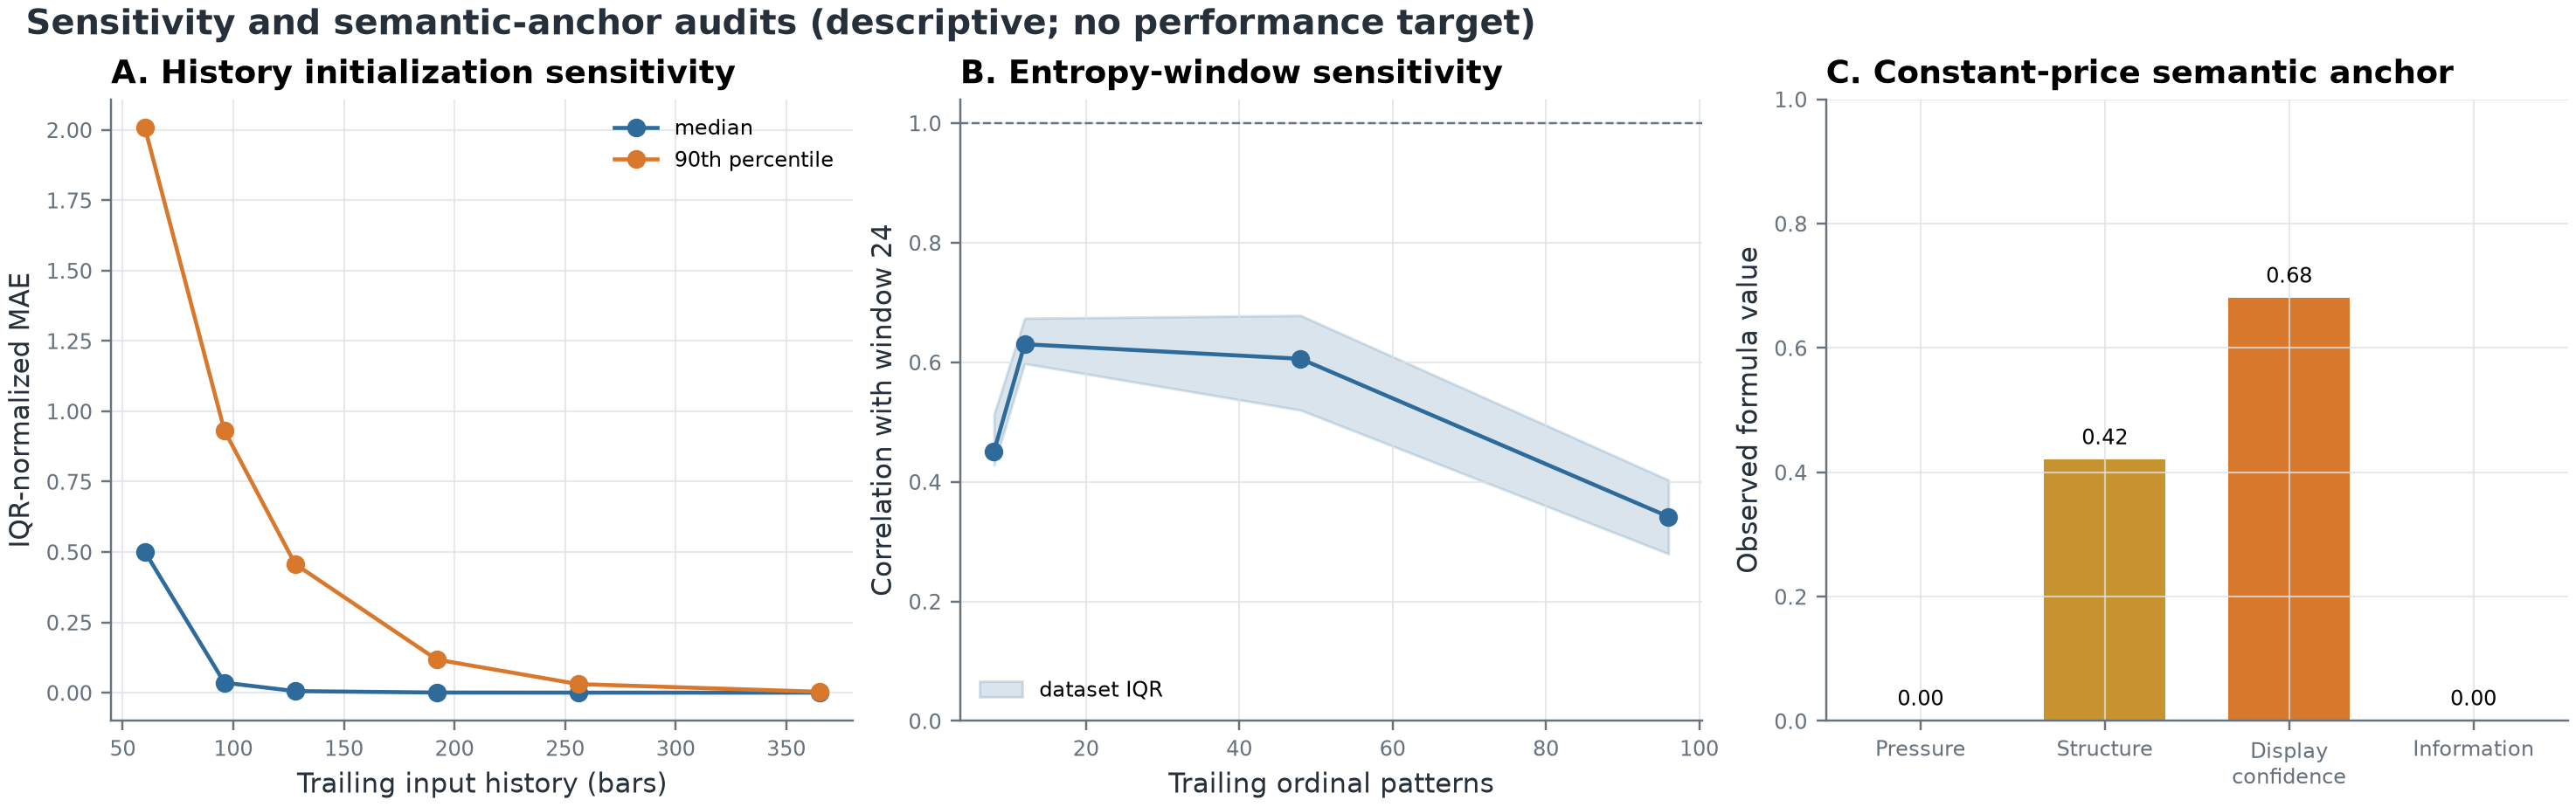

In [4]:
history = pd.read_csv(HERE / "results" / "history_truncation_sensitivity.csv")
entropy = pd.read_csv(HERE / "results" / "entropy_window_sensitivity.csv")
initialization = pd.read_csv(HERE / "results" / "initialization_contracts.csv")
null_state = pd.read_csv(HERE / "results" / "null_state_anchor.csv")
display(pd.DataFrame(summary["history_truncation"]["window_summary"]))
display(initialization)
display(null_state)
display(
    entropy[entropy["window_patterns"] != 24]
    .groupby("window_patterns", as_index=False)["entropy_correlation_vs_window24"]
    .median()
)
display(Image(filename=str(HERE / "figures" / "fig_sensitivity_audits.png")))

,reference_step,horizon_step,comparisons,datasets,features
0,1,1,180,15,12
1,1,2,180,15,12
2,1,4,180,15,12
3,1,8,180,15,12


,dataset_id,feature,iqr_normalized_mae,correlation,final_abs_error
131,spy_15m,scaling_exponent,0.730467,0.910891,0.2589
179,spy_30m,scaling_exponent,0.669802,0.914467,0.1495
227,spy_1h,scaling_exponent,0.569816,0.952888,0.0829
275,spy_2h,scaling_exponent,0.487660,0.911708,0.0602
415,spy_1w,geometry,0.480397,0.841112,0.0163
178,spy_30m,cascade_bias,0.465617,0.817249,0.0380
658,uso_1d,cascade_bias,0.461610,0.821776,0.0549
33,spy_1m,propagation,0.447577,0.905518,0.0188
562,tlt_1d,cascade_bias,0.440544,0.829264,0.0437
271,spy_2h,geometry,0.427717,0.768254,0.0091


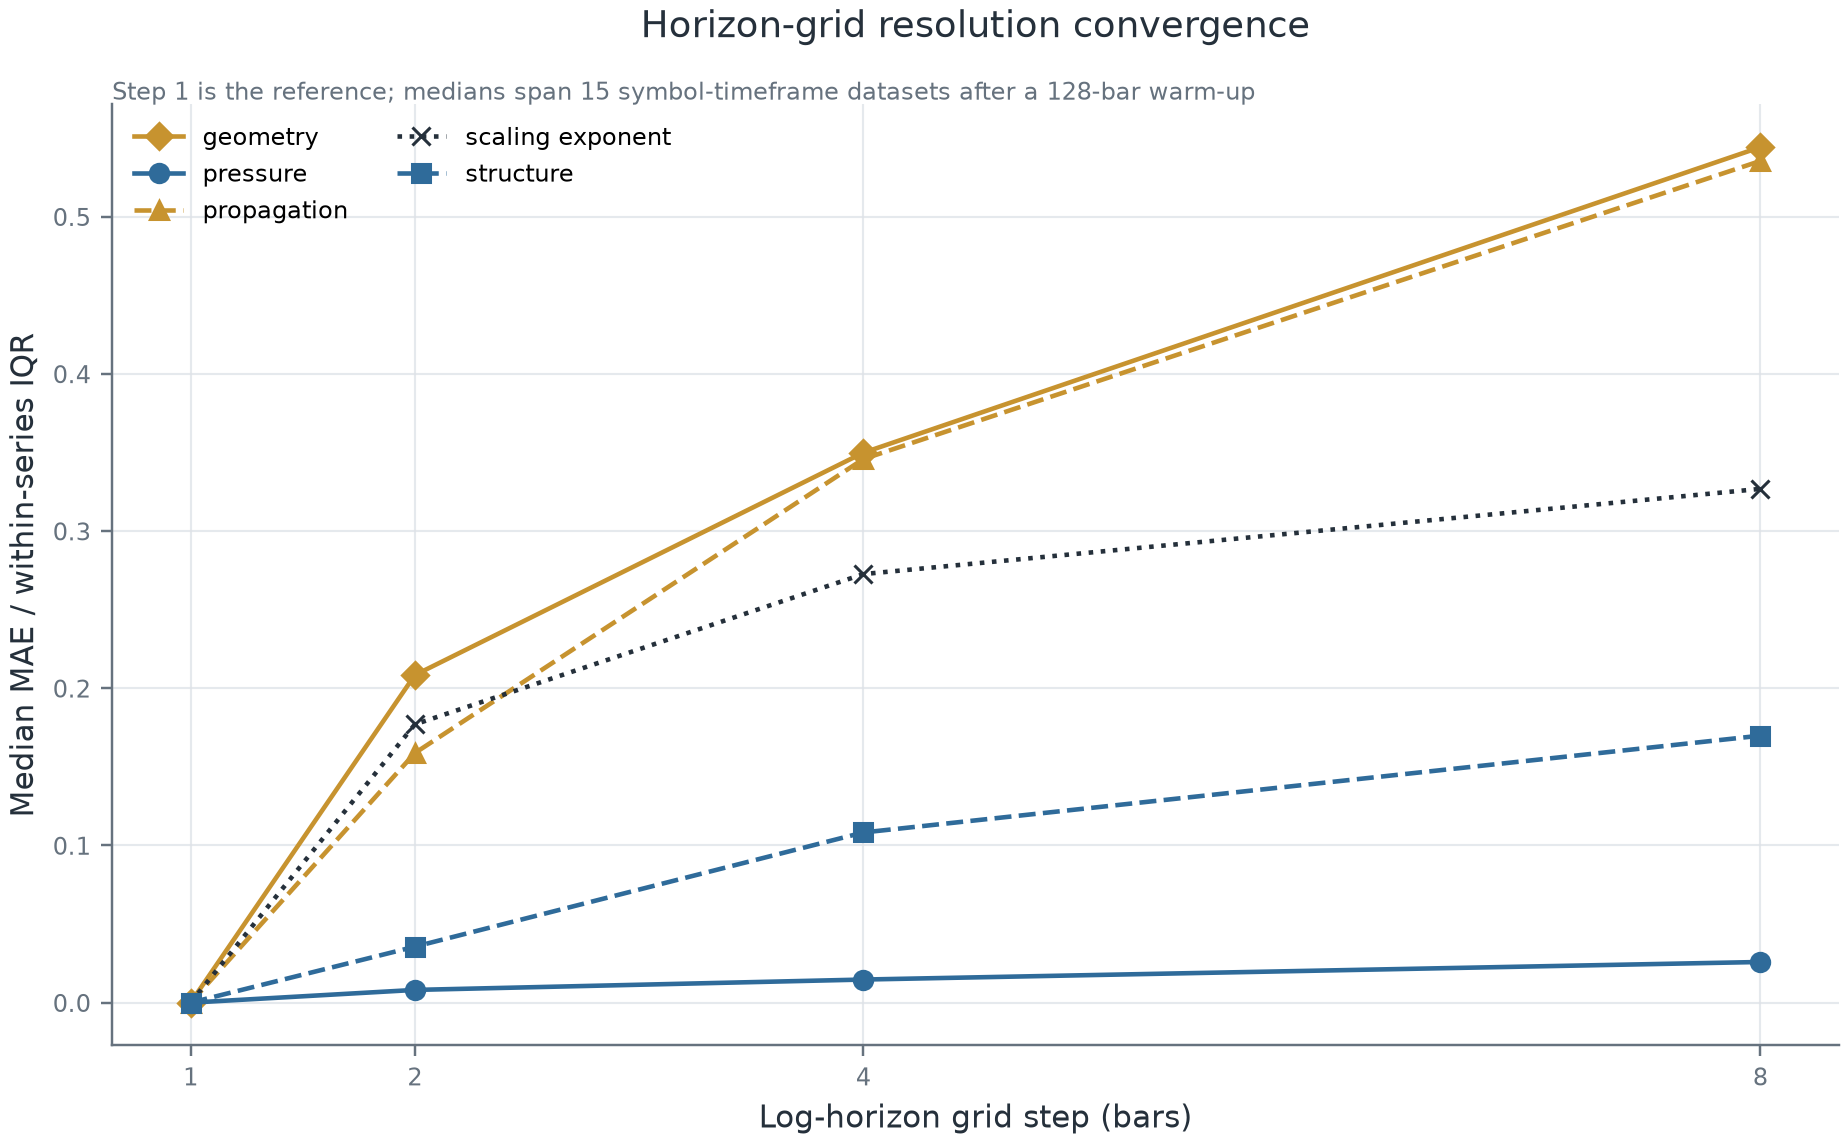

In [5]:
resolution = pd.read_csv(HERE / "results" / "resolution_convergence.csv")
resolution_counts = pd.read_csv(HERE / "results" / "resolution_comparison_counts.csv")
step4 = resolution[resolution["horizon_step"] == 4].sort_values("iqr_normalized_mae", ascending=False)
display(resolution_counts)
display(step4[["dataset_id", "feature", "iqr_normalized_mae", "correlation", "final_abs_error"]].head(12))
display(Image(filename=str(HERE / "figures" / "fig_resolution_convergence.png")))

,timeframe,bars,evaluation_bars,coverage_days,finite_feature_share,pressure_median,pressure_iqr,pressure_lag1_autocorrelation,median_abs_pressure_change,median_abs_velocity,structure_median,geometry_median,information_median,phase_transitions_per_100_bars,median_phase_run_bars,median_phase_run_nominal_minutes,positive_phase_share,neutral_phase_share,negative_phase_share
0,1m,499,403,1.075000,1.0,0.0141,0.12945,0.996272,0.00555,0.3768,0.4483,0.3757,0.4285,3.980100,12.0,12.0,0.451613,0.267990,0.280397
1,5m,499,403,8.833333,1.0,-0.0061,0.09950,0.995882,0.00560,0.3819,0.4403,0.3761,0.4491,5.472637,9.0,45.0,0.312655,0.258065,0.429280
2,15m,499,403,28.041667,1.0,0.0189,0.16525,0.995715,0.00770,0.4060,0.4669,0.3786,0.4263,4.975124,15.0,225.0,0.493797,0.178660,0.327543
3,30m,499,403,56.812500,1.0,-0.0001,0.14655,0.996453,0.00635,0.3763,0.4648,0.3808,0.4417,5.472637,9.0,270.0,0.374690,0.166253,0.459057
4,1h,499,403,104.041667,1.0,0.0460,0.16260,0.996061,0.00700,0.3806,0.4718,0.3811,0.4525,4.726368,8.5,510.0,0.637717,0.116625,0.245658
5,2h,499,403,182.875000,1.0,0.0350,0.21965,0.997580,0.00760,0.3782,0.4659,0.3840,0.4628,2.985075,12.0,1440.0,0.558313,0.146402,0.295285
6,4h,499,403,365.000000,1.0,0.0247,0.11945,0.996965,0.00490,0.3554,0.4362,0.3744,0.4887,5.721393,10.5,2520.0,0.535980,0.305211,0.158809
7,1D,749,653,1091.000000,1.0,0.1111,0.18560,0.996514,0.00690,0.3637,0.4954,0.3845,0.4529,3.987730,8.0,3120.0,0.747320,0.142420,0.110260
8,1W,499,403,3485.958333,1.0,0.1180,0.20890,0.995363,0.00670,0.3735,0.4935,0.3806,0.4394,2.985075,15.0,29250.0,0.761787,0.138958,0.099256


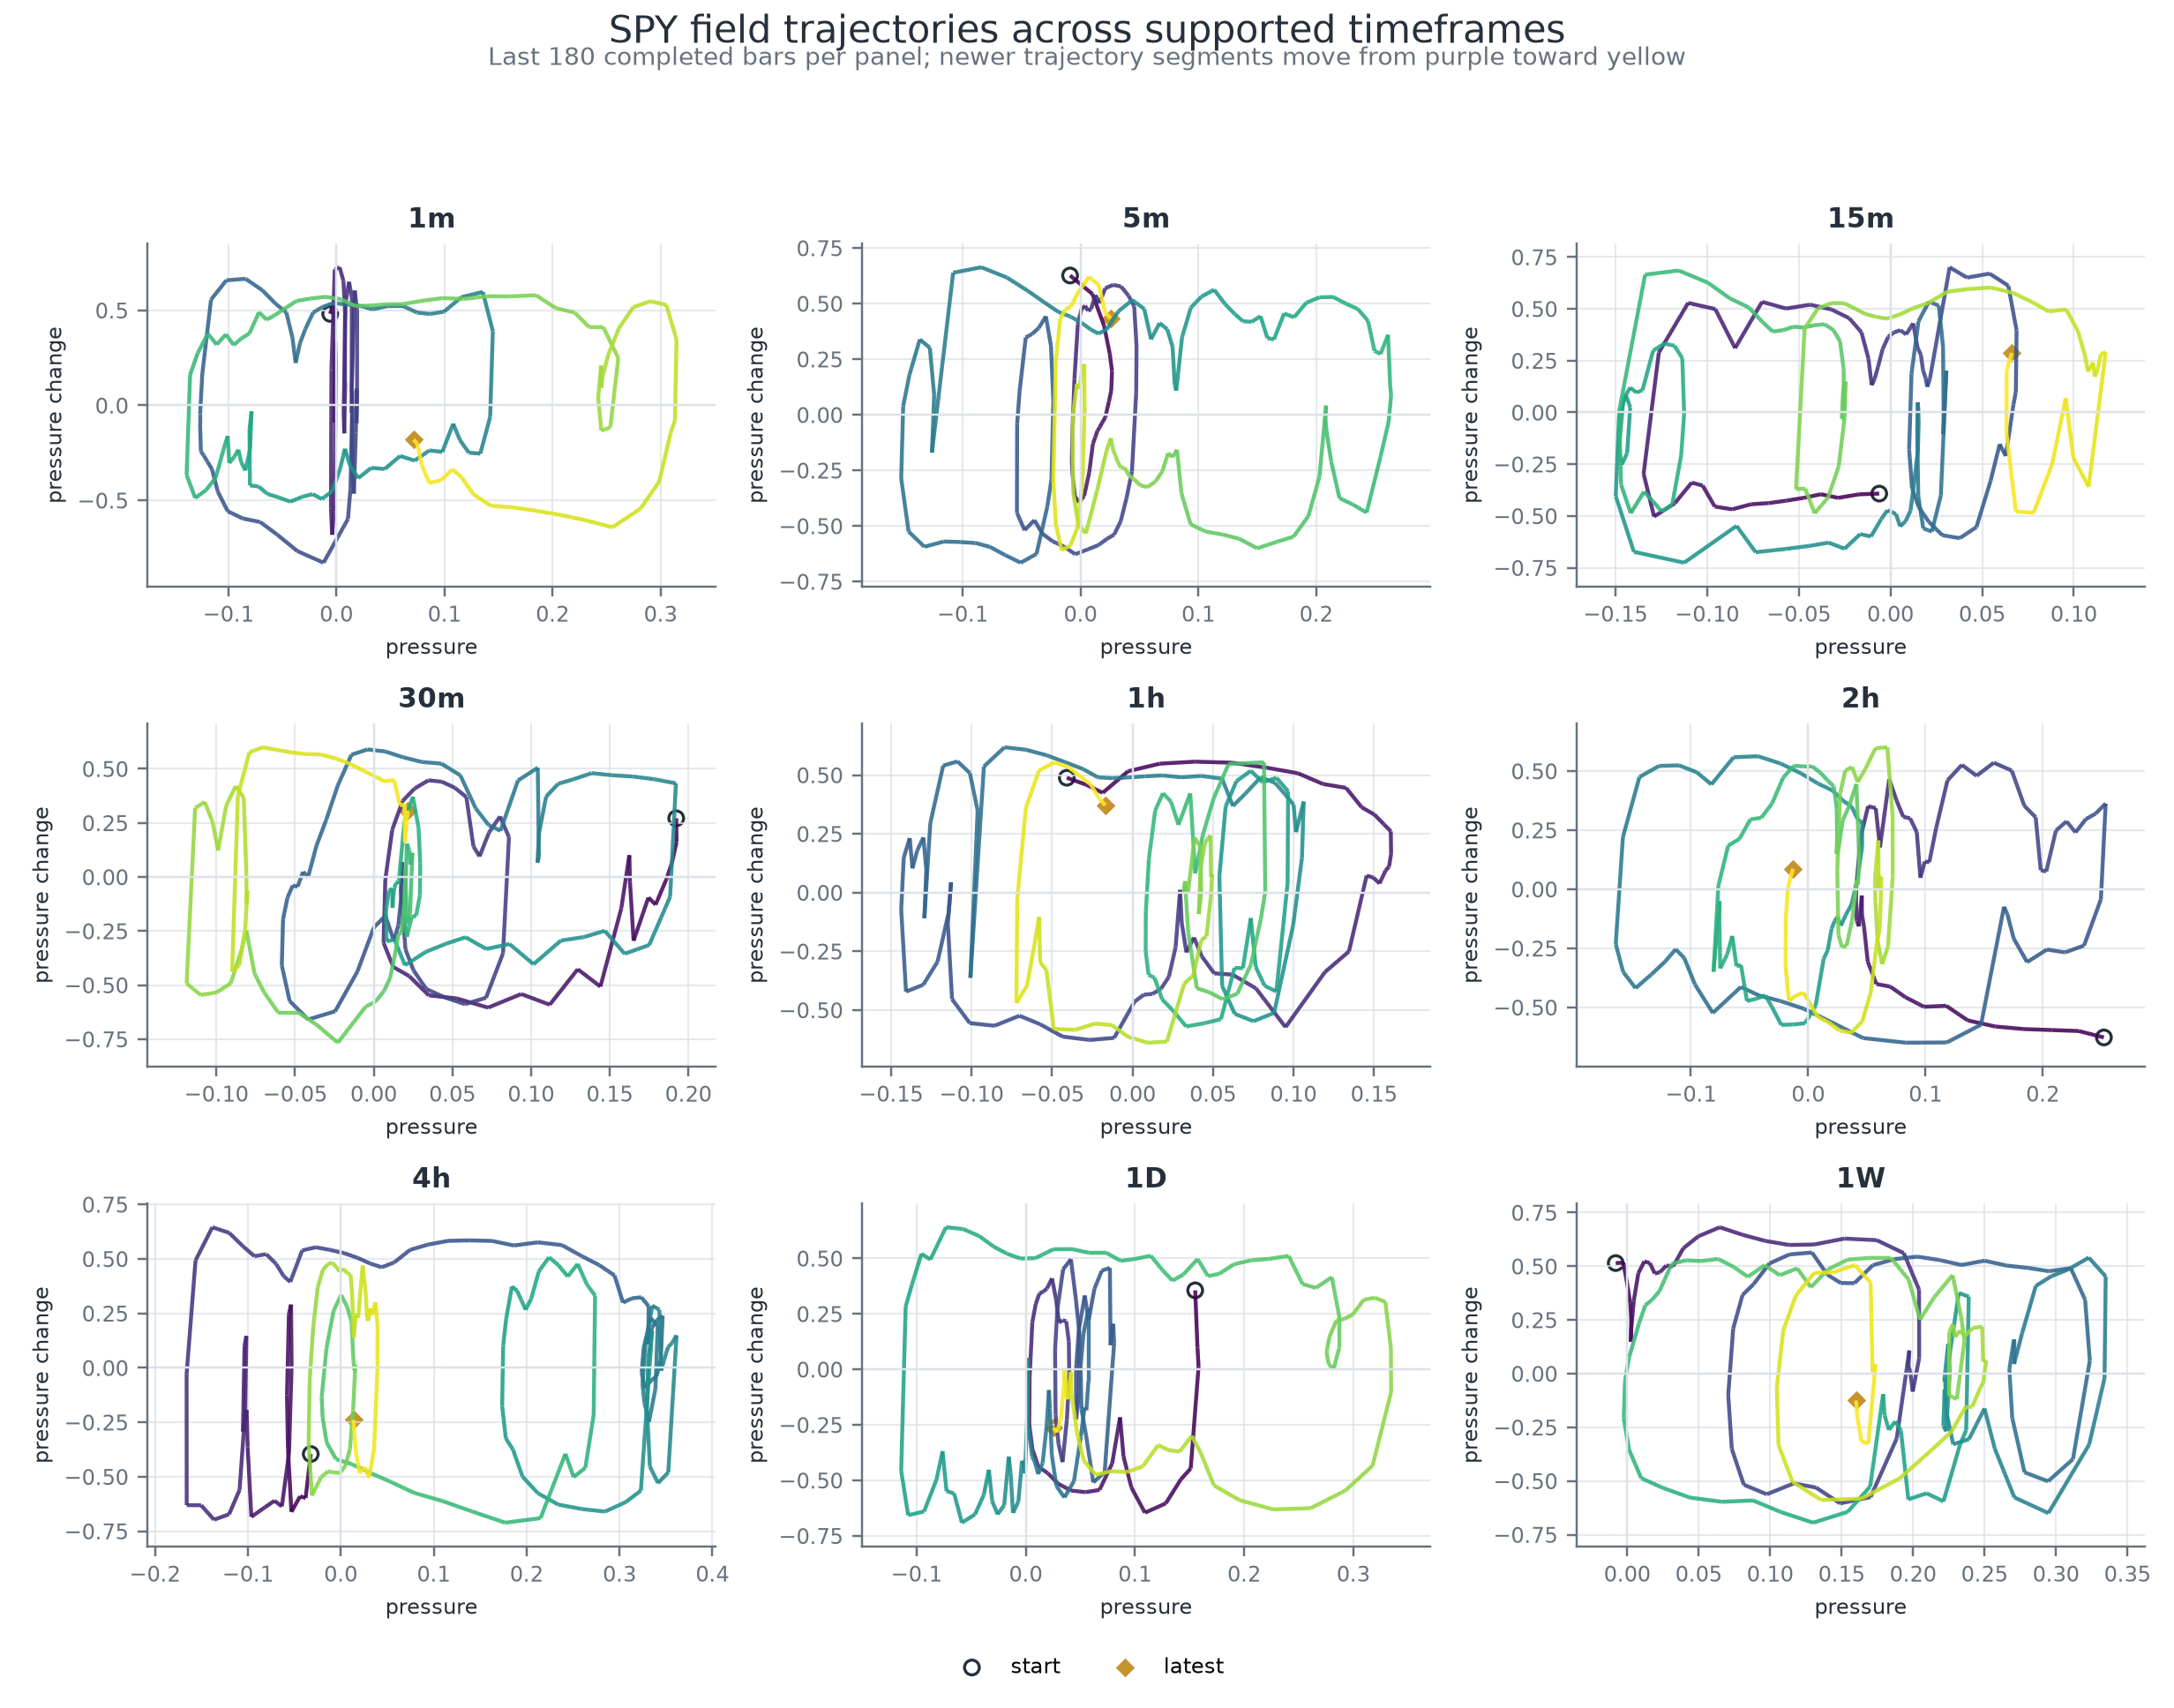

In [6]:
timeframes = pd.read_csv(HERE / "results" / "timeframe_behavior.csv")
display(timeframes)
display(Image(filename=str(HERE / "figures" / "fig_timeframe_phase_portraits.png")))

,dataset_id,archetype_count,fit_mean_silhouette,fit_bars,calibration_bars,evaluation_bars,distance_tail_supported_bars,distance_tail_unsupported_bars,distance_tail_coverage,lower_calibration_tail_count,outside_range_rate_when_scored,evaluation_state_changes,evaluation_median_run_bars,fit_transition_count,reliable_next_state_count,current_state,current_distance_tail_score,current_distance_tail_support
0,spy_1d,2,0.278031,236,117,300,300,0,1.000000,110,0.366667,11,11.5,6,0,F.002,0.509434,52
1,qqq_1d,2,0.251756,236,117,300,300,0,1.000000,128,0.426667,12,9.0,12,2,F.001,0.512821,77
2,iwm_1d,2,0.426800,236,117,300,226,74,0.753333,0,0.000000,10,23.0,4,0,F.001,0.991525,117
3,tlt_1d,2,0.258655,236,117,300,300,0,1.000000,4,0.013333,11,2.5,2,0,F.001,0.904762,62
4,gld_1d,1,0.000000,236,117,300,300,0,1.000000,16,0.053333,0,300.0,0,0,F.001,0.457627,117
5,uso_1d,1,0.000000,236,117,300,300,0,1.000000,48,0.160000,0,300.0,0,0,F.001,0.601695,117
6,btc_usd_1d,2,0.255779,236,117,300,97,203,0.323333,11,0.113402,19,4.0,2,0,F.001,NaN,0


,prefix_fraction,prefix_bars,overlap_bars,full_archetypes,prefix_archetypes,adjusted_rand_index,interpretation
0,0.70,524,75,2,1,0.000000,Window-native dictionary stability diagnostic;...
1,0.85,637,188,2,2,0.872967,Window-native dictionary stability diagnostic;...


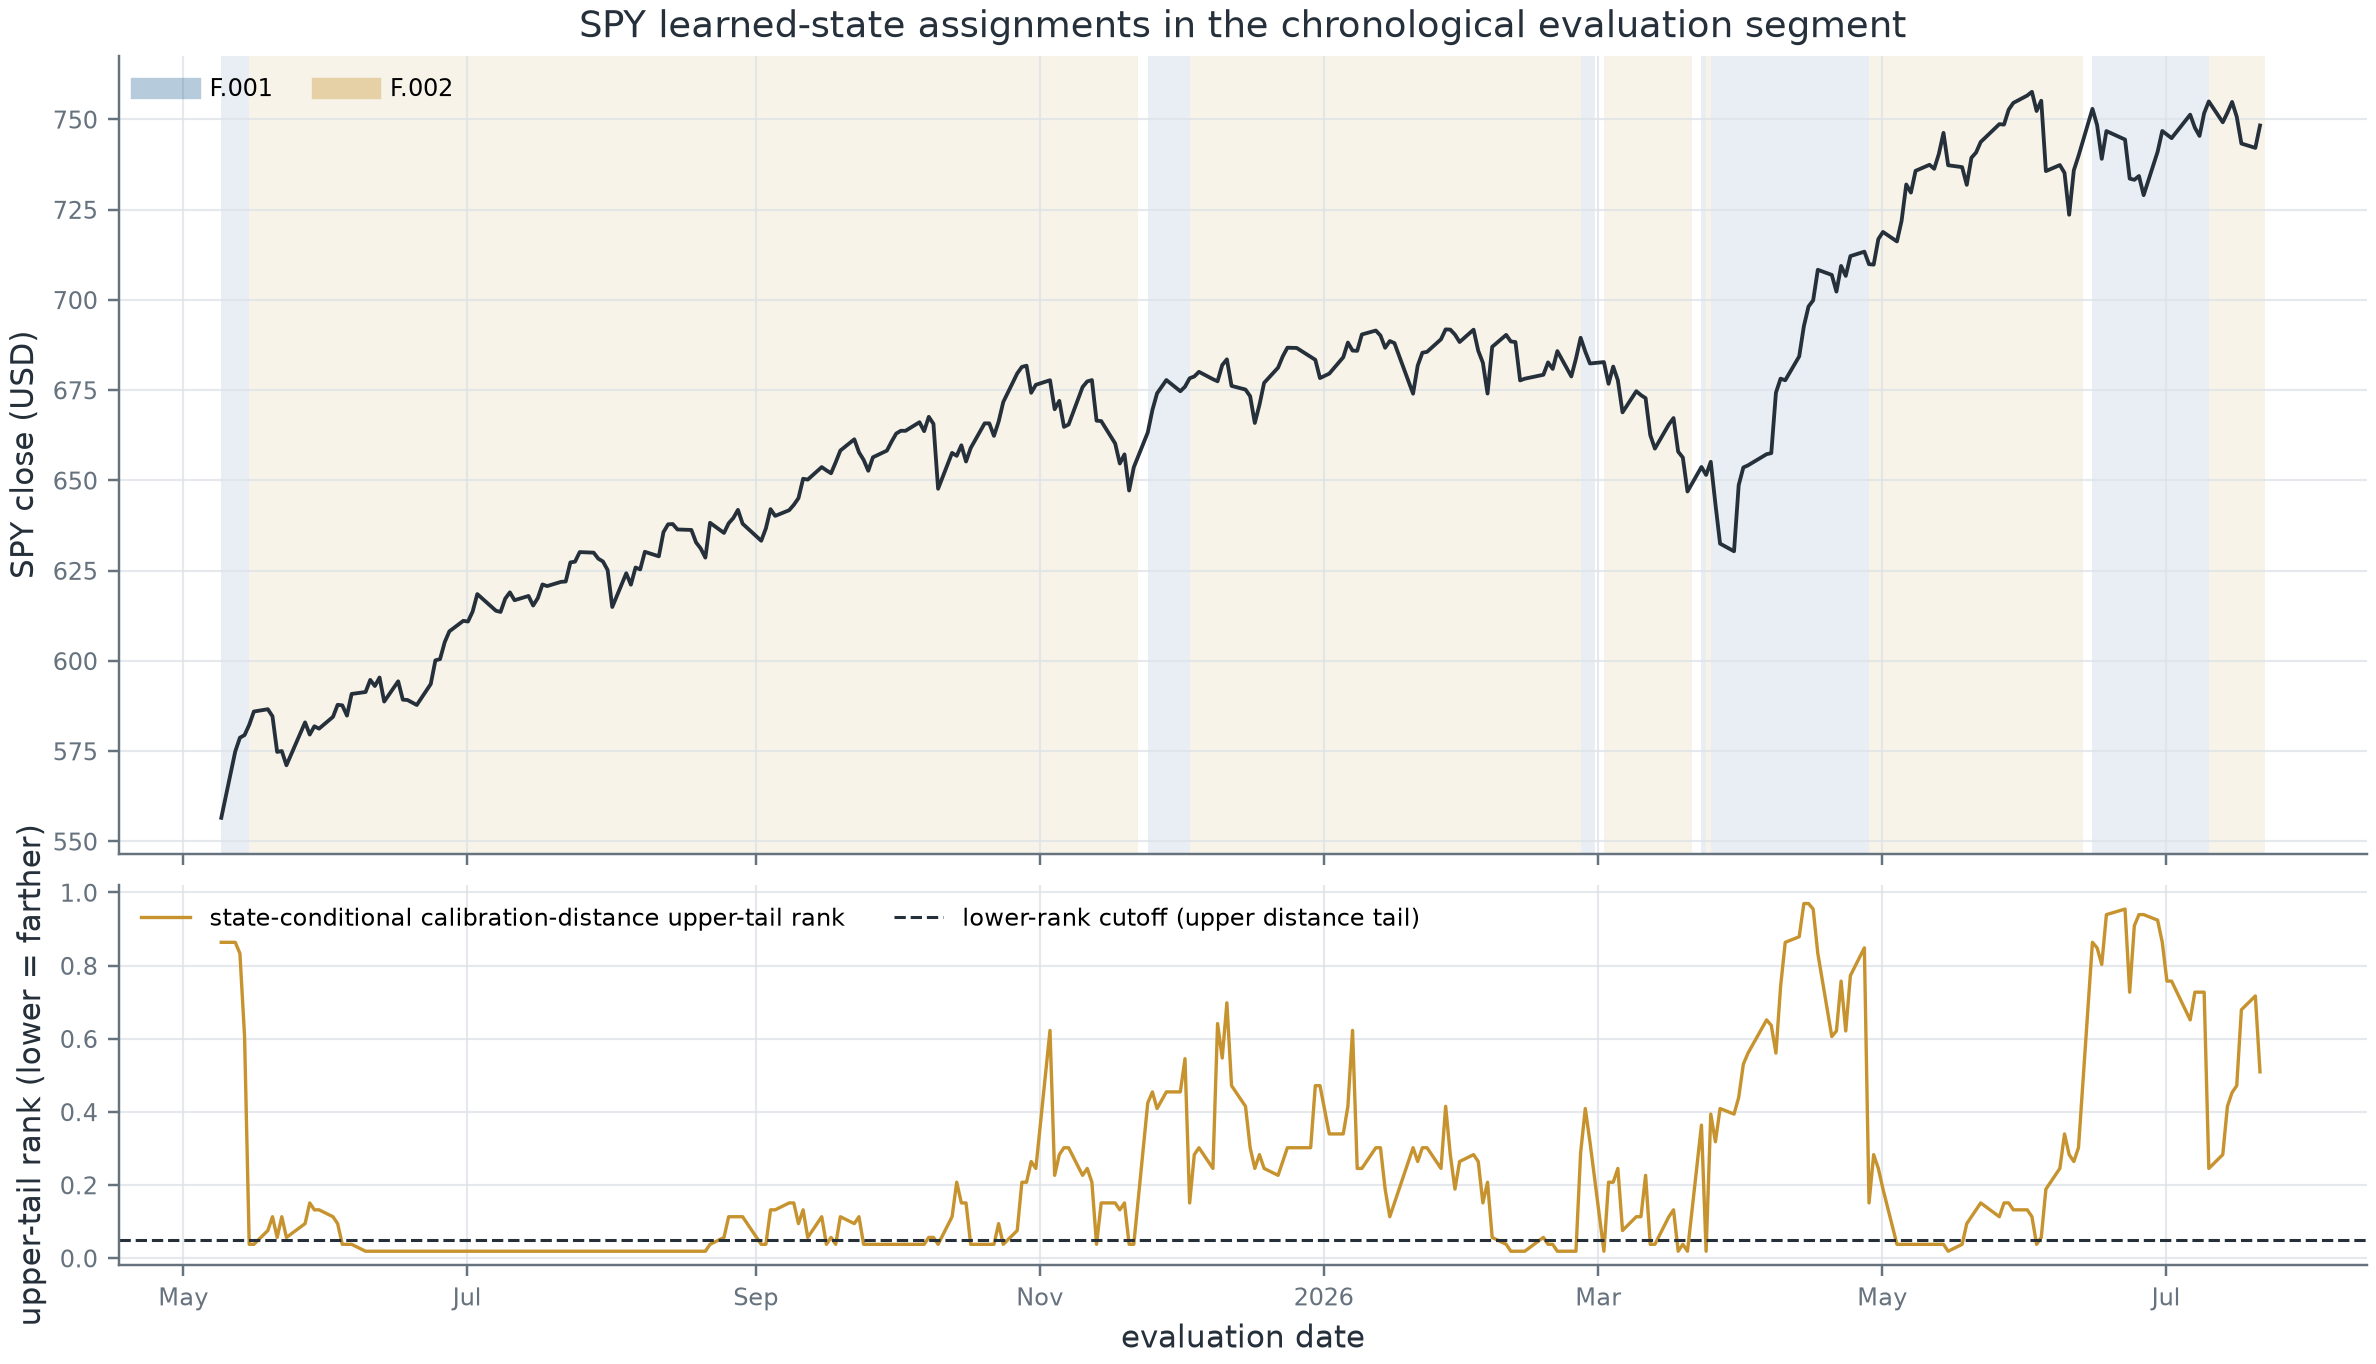

In [7]:
lexicon = pd.read_csv(HERE / "results" / "lexicon_diagnostics.csv")
stability = pd.read_csv(HERE / "results" / "lexicon_window_stability.csv")
display(lexicon)
display(stability)
display(Image(filename=str(HERE / "figures" / "fig_spy_state_timeline.png")))

In [8]:
shadow = json.loads((HERE / "results" / "shadow_boundary.json").read_text(encoding="utf-8"))
live = json.loads((HERE / "results" / "live_endpoint_probe.json").read_text(encoding="utf-8"))
latency = pd.read_csv(HERE / "results" / "option_snapshot_latency.csv")
display(pd.DataFrame([shadow]))
display(pd.DataFrame([summary["option_snapshot_latency"]]))
display(pd.DataFrame([live["summary"]]))

,alignment_sign_flip_holds,as_of_bar,automated_execution_enabled,call_aligned_pressure,call_path_state,completed_bars,completed_bars_only,excluded_incomplete_bars,incomplete_session_has_zero_field_influence,mode,model_version,performance_claim_evaluated,put_aligned_pressure,put_path_state,rank_influence,retrospective_sections_excluded,schema_version,synthetic_incomplete_session_appended
0,True,2026-07-21,False,0.0255,fading,365,True,1,True,shadow_only,market_field_calculus_v1,False,-0.0255,contradictory,0.0,True,option_market_field_v1,True


,all_max_ms,environment,exclusions,first_measured_max_ms,runs,symbols,warm_p50_ms,warm_p95_ms,warm_p99_ms,warm_runs
0,133.0185,"{'platform': 'Windows-11-10.0.26200-SP0', 'pro...","[data retrieval, persistence, concurrent load,...",133.0185,70,7,111.3566,121.07383,126.245846,63


,median_elapsed_ms,possible_incomplete_latest_bars,successful_timeframes,timeframes
0,6409.8,9,9,9


## Takeaways

1. **Tested nonanticipativity and determinism are strong.** Fixed local inputs yielded exact prefix agreement before response rounding and exact repeated hashes in every audit performed.
2. **Computable is not converged.** The audited 60-bar option baseline was much more initialization-sensitive than 128–365-bar histories. Semantic revision 1.2 requires 96 completed bars and discloses minimum-input and initialization-target coverage, but that threshold is not a convergence guarantee. The serialized `maturity` object remains only a legacy alias.
3. **Grid density and entropy window are model parameters.** Neither has been shown optimal, and both materially alter descriptive measurements.
4. **Flat-state formula floors need semantic care.** Structure 0.42 and display confidence 0.68 on constant prices are coherence-derived anchors, not evidence of direction or conviction.
5. **Cross-timeframe rendering is feasible, but adjacent bars are not independent evidence.** Every evaluated feature was finite, while pressure lag-one autocorrelation exceeded 0.995 on every SPY timeframe.
6. **The dictionary is currently descriptive.** It is sparse, window-native, has 277 unsupported evaluation bars in this snapshot, and its 0.05 distance-tail rank is not uniformly calibrated forward in time.
7. **Options context has zero algorithmic authority, not zero human influence.** The wrapper passed completed-bar, sign-alignment, no-retrospective-state, no-ranking-influence, and no-automation checks. No option performance was tested.
8. **Latency evidence is deliberately narrow.** The measured distribution is sequential and compute-only; live, cold-start, concurrent, and production-tail performance remain unevaluated.

See `PRELIMINARY_EVALUATION.md` for exact claim boundaries and the proposed walk-forward performance protocol.